# Chapter 8d — Bifurcations and Chaos

This notebook covers the last six scripts of Chapter 8's physical-climate-
science group, `chap8_physic4f`, `chap8_physic4g`, and `chap8_physic5a`
through `chap8_physic5d`. Unlike `08c` (which built one specific bistable
ice-albedo climate model), these scripts step back to *generic* dynamical-
systems theory: the standard bifurcation "normal forms" that show up
whenever a real system (ice-albedo, permafrost, AMOC, ...) develops
multiple equilibria, plus a worked chaotic system (the Rössler attractor)
and an illustration of how one tipping element can push a second one past
its own threshold ("cascading" or "coupled" tipping points).

All of the models here are first-principles / textbook dynamical systems —
no external data.

**A note on `08d_physic4g` (the Rössler bifurcation diagrams):** the source
MATLAB script solves the Rössler ODE system roughly **950 times** (three
parameter sweeps of ~370, ~400, and ~180 points respectively, each
integrated over a 5000-point time grid) purely to build the classic
"bifurcation diagram" scatter plots. Reproducing that exact grid density in
Python/`solve_ivp` would take on the order of 10 minutes of pure computation
for what is a supplementary illustrative figure. This notebook instead uses
**half the grid density** (~475 total solves) with a tighter integrator
tolerance than SciPy's default, which reproduces the same qualitative
bifurcation structure (period-doubling windows, periodic windows, broadband
chaos) in about half the time. This is a deliberate, documented resolution
reduction — not a shortcut taken silently.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from scipy.integrate import solve_ivp

color_blue    = np.array([  0,  20, 255]) / 255
color_red     = np.array([255,  80,  50]) / 255
color_green   = np.array([ 20, 200,  80]) / 255
color_violet  = np.array([255,  51, 255]) / 255
color_teal    = np.array([ 56, 142, 142]) / 255
color_gray    = np.array([150, 150, 150]) / 255
color_black   = np.array([0, 0, 0])

def missex(x, cond):
    # GAUSS `missex(x, m)`: replace x with NaN wherever the condition m is true, else keep x.
    x = np.asarray(x, dtype=float).copy()
    x = x.copy()
    x[np.asarray(cond, dtype=bool)] = np.nan
    return x

def bisection(f, a, b, tol=1e-10, max_iter=200):
    # Matches QuantToolbox/optim/bisection.m exactly: NaN if a and b don't bracket a root.
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return np.nan
    if fa == 0:
        return a
    if fb == 0:
        return b
    for _ in range(max_iter):
        m = (a + b) / 2
        fm = f(m)
        if abs(fm) < tol or (b - a) / 2 < tol:
            return m
        if np.sign(fm) == np.sign(fa):
            a, fa = m, fm
        else:
            b = m
    return (a + b) / 2


## 1. Bifurcation normal forms (`chap8_physic4f`)

Four canonical local bifurcations of a scalar ODE $\dot{x} = f(x;\mu)$, each
shown as its "unfolding diagram" — the equilibria $x^\star(\mu)$ as the
control parameter $\mu$ is varied, stable branches in green (solid),
unstable branches in red (dashed):

- **Saddle-node**: $\dot x = \mu + x^2$ — two equilibria $x^\star=\pm\sqrt{-\mu}$
  exist for $\mu \le 0$ and annihilate each other at $\mu=0$. This is exactly
  the mechanism behind `08c`'s ice-albedo fold points.
- **Transcritical**: $\dot x = \mu x - x^2$ — two equilibria $x^\star=0$ and
  $x^\star=\mu$ exist for all $\mu$ and *exchange stability* as they cross at
  $\mu=0$.
- **Supercritical pitchfork**: $\dot x = \mu x - x^3$ — $x^\star=0$ is the
  only (stable) equilibrium for $\mu<0$; at $\mu=0$ it goes unstable and two
  new stable branches $x^\star=\pm\sqrt\mu$ emerge smoothly.
- **Subcritical pitchfork**: $\dot x = \mu x + x^3 - x^5$ — the destabilizing
  cubic term means the two new branches appear *discontinuously*, at a
  saddle-node fold *before* $\mu=0$, producing hysteresis exactly like the
  ice-albedo model's own three-equilibria structure.


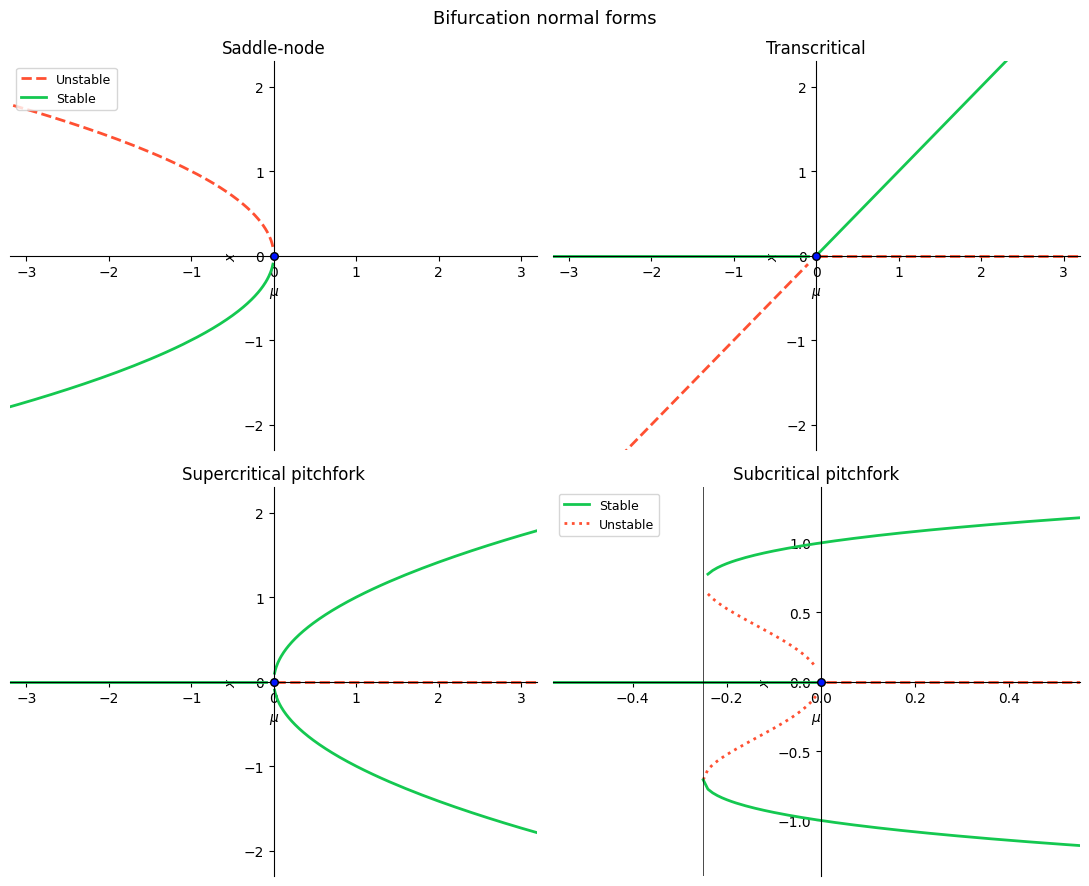

In [2]:

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# --- Saddle-node: x' = mu + x^2, x* = +/- sqrt(-mu), valid for mu <= 0 ---
ax = axes[0, 0]
mu = np.concatenate([np.arange(-5, -1, 0.1), np.arange(-1, 0, 0.01), np.arange(0, 5.01, 0.1)])
mu_minus = missex(mu, mu >= 0)
y1 = np.sqrt(-mu_minus)
y2 = -np.sqrt(-mu_minus)
ax.plot(mu_minus, y1, "--", color=color_red, linewidth=2.0, label="Unstable")
ax.plot(mu_minus, y2, "-", color=color_green, linewidth=2.0, label="Stable")
ax.scatter([0], [0], s=30, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$x$"); ax.set_title("Saddle-node")
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-2.3, 2.3)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False); ax.spines["top"].set_visible(False)
ax.legend(loc="upper left", fontsize=9)

# --- Transcritical: x' = mu*x - x^2, x* = 0 or x* = mu ---
ax = axes[0, 1]
mu = np.concatenate([np.arange(-5, 0, 0.1), np.arange(0, 1, 0.01), np.arange(1, 5.01, 0.1)])
mu_minus = missex(mu, mu >= 0)
mu_plus = missex(mu, mu <= 0)
ax.plot(mu_minus, mu_minus, "--", color=color_red, linewidth=2.0)
ax.plot(mu_plus, mu_plus, "-", color=color_green, linewidth=2.0)
ax.plot(mu_plus, np.zeros_like(mu_plus), "--", color=color_red, linewidth=2.0)
ax.plot(mu_minus, np.zeros_like(mu_minus), "-", color=color_green, linewidth=2.0)
ax.scatter([0], [0], s=30, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$x$"); ax.set_title("Transcritical")
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-2.3, 2.3)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False); ax.spines["top"].set_visible(False)

# --- Supercritical pitchfork: x' = mu*x - x^3, x* = 0 or x* = +/- sqrt(mu) ---
ax = axes[1, 0]
mu = np.concatenate([np.arange(-5, 0, 0.1), np.arange(0, 1, 0.01), np.arange(1, 5.01, 0.1)])
mu_minus = missex(mu, mu >= 0)
mu_plus = missex(mu, mu <= 0)
ax.plot(mu_minus, np.zeros_like(mu_minus), "-", color=color_green, linewidth=2.0)
ax.plot(mu_plus, np.zeros_like(mu_plus), "--", color=color_red, linewidth=2.0)
ax.plot(mu_plus, np.sqrt(mu_plus), "-", color=color_green, linewidth=2.0)
ax.plot(mu_plus, -np.sqrt(mu_plus), "-", color=color_green, linewidth=2.0)
ax.scatter([0], [0], s=30, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$x$"); ax.set_title("Supercritical pitchfork")
ax.set_xlim(-3.2, 3.2); ax.set_ylim(-2.3, 2.3)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False); ax.spines["top"].set_visible(False)

# --- Subcritical pitchfork: x' = mu*x + x^3 - x^5, roots of -x^5+x^3+mu*x = 0 ---
ax = axes[1, 1]
mu = np.concatenate([np.arange(-5, -0.30, 0.1), np.arange(-0.30, 0, 0.01),
                      np.arange(0, 1, 0.01), np.arange(1, 5.01, 0.1)])
n = len(mu)
mu_minus = missex(mu, mu >= 0)
mu_plus = missex(mu, mu <= 0)
y3 = np.full(n, np.nan)  # stable,  x > 0
y4 = np.full(n, np.nan)  # unstable, x > 0
y5 = np.full(n, np.nan)  # unstable, x < 0
y6 = np.full(n, np.nan)  # stable,  x < 0

for i in range(n):
    roots = np.roots([-1, 0, 1, 0, mu[i], 0])
    for r in roots:
        if abs(r.imag) > 1e-9:
            continue
        x = r.real
        lam = -5 * x**4 + 3 * x**2 + mu[i]
        if lam < 0 and x > 0:
            y3[i] = x
        elif lam > 0 and x > 0:
            y4[i] = x
        elif lam > 0 and x < 0:
            y5[i] = x
        elif lam < 0 and x < 0:
            y6[i] = x

ax.plot(mu_minus, np.zeros_like(mu_minus), "-", color=color_green, linewidth=2.0)
ax.plot(mu_plus, np.zeros_like(mu_plus), "--", color=color_red, linewidth=2.0)
l_stable, = ax.plot(mu, y3, "-", color=color_green, linewidth=2.0)
l_unstable, = ax.plot(mu, y4, ":", color=color_red, linewidth=2.0)
ax.plot(mu, y5, ":", color=color_red, linewidth=2.0)
ax.plot(mu, y6, "-", color=color_green, linewidth=2.0)
ax.plot([-0.25, -0.25], [-3, 3], "-", color=color_black, linewidth=0.5)
ax.scatter([0], [0], s=30, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.set_xlabel(r"$\mu$"); ax.set_ylabel(r"$x$"); ax.set_title("Subcritical pitchfork")
ax.set_xlim(-0.57, 0.55); ax.set_ylim(-1.4, 1.4)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False); ax.spines["top"].set_visible(False)
ax.legend([l_stable, l_unstable], ["Stable", "Unstable"], loc="upper left", fontsize=9)

fig.suptitle("Bifurcation normal forms", fontsize=13)
plt.tight_layout()
plt.show()


## 2. The Rössler chaotic attractor and its bifurcation diagrams (`chap8_physic4g`)

The Rössler system

$$\dot x = -y-z,\qquad \dot y = x+ay,\qquad \dot z = b+xz-cz$$

is a minimal 3-D ODE system that produces a chaotic attractor for a wide
range of parameters. At the textbook parameters $(a,b,c)=(0.2,0.2,5.7)$ the
trajectory spirals in a plane, occasionally "kicks" out in $z$, and returns —
tracing the well-known Rössler band.

The three bifurcation diagrams sweep one parameter at a time (holding the
other two at $a=0.2,\,b=0.2,\,c=5.7$ except where the swept parameter *is*
$b$, which uses $a=0.2,\,c=5.7$ per the source), and for each parameter
value plot every **local maximum** of $x(t)$ after discarding the initial
transient ($t>100$ out of a $t\in[0,500]$ integration). Stacking those local
maxima vertically at each parameter value produces the classic bifurcation
diagram: a single point means a stable periodic orbit, a vertical smear of
points means chaos, and period-doubling shows up as the single point
splitting into two, then four, and so on.


Sweeping 185 + 199 + 90 = 474 parameter values (reduced grid, see markdown note above)...


attractor done.


a-sweep done.


b-sweep done.


c-sweep done.


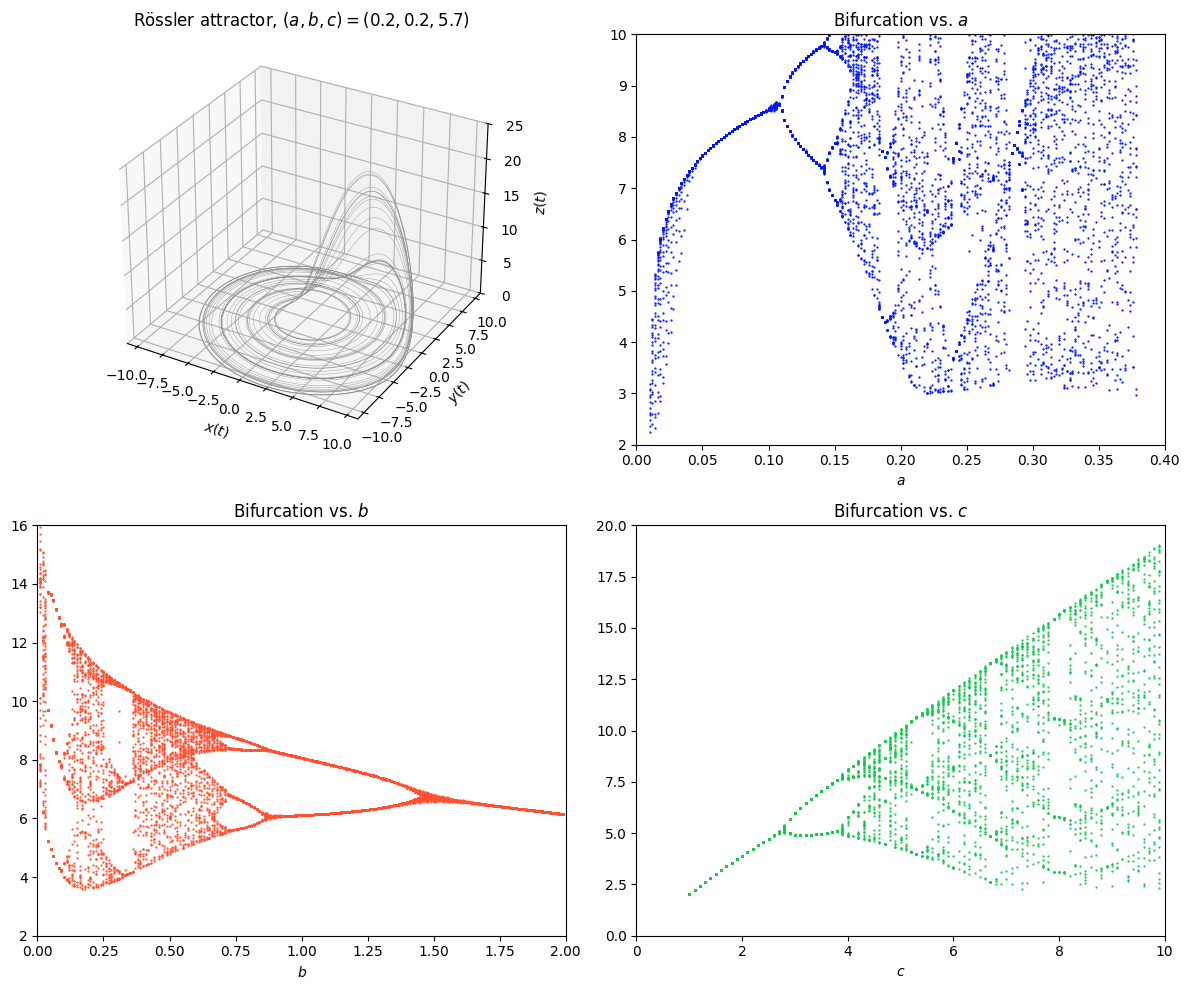

In [3]:

def rossler(t, x, a, b, c):
    x1, x2, x3 = x
    return [-x2 - x3, x1 + a * x2, b + x1 * x3 - c * x3]

x0 = [1.0, 1.0, 0.0]

# --- Peak-detection bifurcation-diagram helper (reduced grid density, see note above) ---
t_range = np.arange(0, 500, 0.1)
cnd = t_range > 100
delta = 0.01

def peaks_of_x(a, b, c):
    sol = solve_ivp(rossler, [t_range[0], t_range[-1]], x0, t_eval=t_range,
                     args=(a, b, c), method="RK45", rtol=1e-6, atol=1e-9)
    x1 = sol.y[0][cnd]
    pk = x1[1:-1][(x1[:-2] + delta < x1[1:-1]) & (x1[1:-1] > x1[2:] + delta)]
    return pk

a_range = np.arange(0.01, 0.38, 0.002)
b_range = np.arange(0.01, 2.00, 0.01)
c_range = np.arange(1.0, 10.0, 0.1)

print(f"Sweeping {len(a_range)} + {len(b_range)} + {len(c_range)} = "
      f"{len(a_range) + len(b_range) + len(c_range)} parameter values "
      f"(reduced grid, see markdown note above)...")

# Everything below builds into ONE figure in ONE cell (Jupyter's inline backend
# auto-closes a figure at the end of each cell, so splitting this across cells
# would silently drop panels 2-4).
fig = plt.figure(figsize=(12, 10))

# --- Panel 1: the attractor itself, at (a,b,c) = (0.2, 0.2, 5.7) ---
ax1 = fig.add_subplot(2, 2, 1, projection="3d")
sol = solve_ivp(rossler, [0, 400], x0, args=(0.2, 0.2, 5.7), method="RK45",
                 rtol=1e-8, atol=1e-9, dense_output=True)
t_dense = np.linspace(200, 400, 20000)
x_dense = sol.sol(t_dense)
ax1.plot(x_dense[0], x_dense[1], x_dense[2], "-", color=color_gray, linewidth=0.3)
ax1.set_xlabel("$x(t)$"); ax1.set_ylabel("$y(t)$"); ax1.set_zlabel("$z(t)$")
ax1.set_xlim(-11, 11); ax1.set_ylim(-11, 11); ax1.set_zlim(0, 25)
ax1.set_title("Rössler attractor, $(a,b,c)=(0.2, 0.2, 5.7)$")
print("attractor done.")

# --- Panel 2: sweep over a, holding b=0.2, c=5.7 ---
ax2 = fig.add_subplot(2, 2, 2)
for a in a_range:
    pk = peaks_of_x(a, 0.2, 5.7)
    ax2.plot(np.full_like(pk, a), pk, ".", markersize=1.2, color=color_blue)
ax2.set_xlabel("$a$")
ax2.set_xlim(0.0, 0.4); ax2.set_ylim(2, 10)
ax2.set_title("Bifurcation vs. $a$")
print("a-sweep done.")

# --- Panel 3: sweep over b, holding a=0.2, c=5.7 ---
ax3 = fig.add_subplot(2, 2, 3)
for b in b_range:
    pk = peaks_of_x(0.2, b, 5.7)
    ax3.plot(np.full_like(pk, b), pk, ".", markersize=1.2, color=color_red)
ax3.set_xlabel("$b$")
ax3.set_xlim(0, 2); ax3.set_ylim(2, 16)
ax3.set_title("Bifurcation vs. $b$")
print("b-sweep done.")

# --- Panel 4: sweep over c, holding a=0.2, b=0.2 ---
ax4 = fig.add_subplot(2, 2, 4)
for c in c_range:
    pk = peaks_of_x(0.2, 0.2, c)
    ax4.plot(np.full_like(pk, c), pk, ".", markersize=1.2, color=color_green)
ax4.set_xlabel("$c$")
ax4.set_xlim(0, 10); ax4.set_ylim(0, 20)
ax4.set_title("Bifurcation vs. $c$")
print("c-sweep done.")

plt.tight_layout()
plt.show()


## 3. Cubic normal form: fold diagram (`chap8_physic5a`)

A generic "tipping element" is often modeled with the cubic normal form

$$\dot x = \frac{\alpha x - \beta x^3 + \mu}{\tau}$$

For $\alpha=\beta=\tau=1$ this has up to three real equilibria depending on
$\mu$; the two folds (saddle-node points) sit exactly at
$\mu=\mp\sqrt{4/27},\ x=\pm\sqrt{1/3}$ — between them the system is
*bistable* (three equilibria: two stable, one unstable), giving the
S-shaped hysteresis curve characteristic of tipping elements.


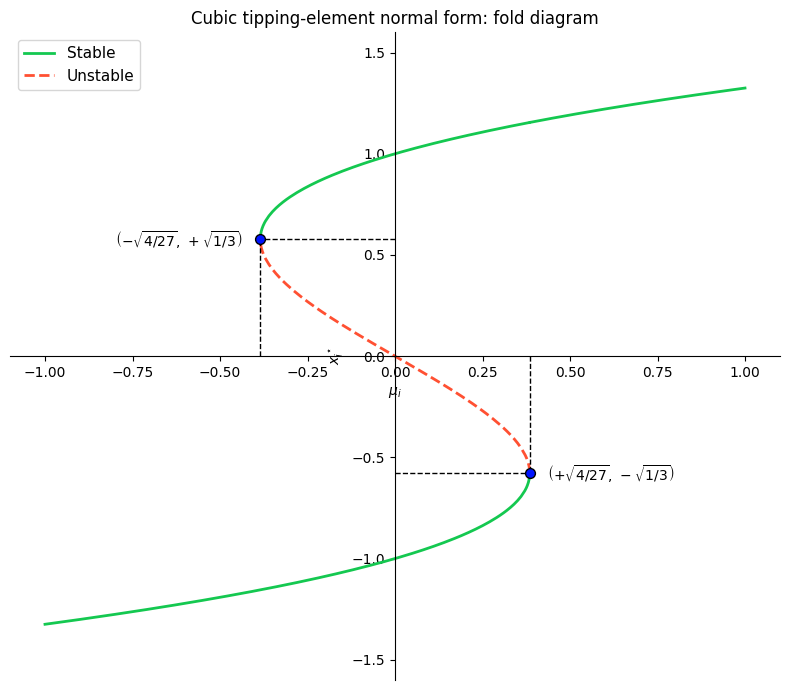

In [4]:

alpha, beta, tau = 1.0, 1.0, 1.0

mu = np.concatenate([
    np.arange(-1.00, -0.39, 0.01), np.arange(-0.39, -0.37, 0.001),
    np.arange(-0.37, 0.37, 0.01), np.arange(0.37, 0.39, 0.001),
    np.arange(0.39, 1.001, 0.01),
])
n = len(mu)
x_star = np.full((n, 3), np.nan)

for i in range(n):
    c = np.array([-beta, 0, alpha, mu[i]]) / tau
    roots = np.roots(c)
    x = np.sort(roots[np.abs(roots.imag) < 1e-9].real)
    stability = (alpha - 3 * beta * x**2) / tau
    m = len(x)

    col = [None] * 3
    if stability[0] < 0:
        col[0] = x[0]
    elif stability[0] > 0:
        col[1] = x[0]
    if m >= 2:
        if stability[1] < 0:
            col[2] = x[1]
        elif stability[1] > 0:
            col[1] = x[1]
    if m >= 3:
        if stability[2] < 0:
            col[2] = x[2]
        elif stability[2] > 0:
            col[1] = x[1]  # matches the source's own (slightly redundant) assignment
    x_star[i, :] = [v if v is not None else np.nan for v in col]

mu0 = np.sqrt(4 / 27)
near_fold = (mu > mu0 - 0.0001) & (mu < mu0 + 0.0001)
x_star[near_fold, :] = np.nan

fig, ax = plt.subplots(figsize=(8, 7))
l_stable, = ax.plot(mu, x_star[:, 0], "-", color=color_green, linewidth=2.0)
l_unstable, = ax.plot(mu, x_star[:, 1], "--", color=color_red, linewidth=2.0)
ax.plot(mu, x_star[:, 2], "-", color=color_green, linewidth=2.0)

mu_fold_left, x_fold_left = -np.sqrt(4 / 27), np.sqrt(1 / 3)
ax.scatter([mu_fold_left], [x_fold_left], s=50, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.plot([mu_fold_left, mu_fold_left], [0, x_fold_left], "--", color=color_black, linewidth=1.0)
ax.plot([0, mu_fold_left], [x_fold_left, x_fold_left], "--", color=color_black, linewidth=1.0)
ax.annotate(r"$\left(-\sqrt{4/27},\,+\sqrt{1/3}\right)$", xy=(mu_fold_left - 0.05, x_fold_left),
            ha="right", va="center", fontsize=10)

mu_fold_right, x_fold_right = np.sqrt(4 / 27), -np.sqrt(1 / 3)
ax.scatter([mu_fold_right], [x_fold_right], s=50, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.plot([mu_fold_right, mu_fold_right], [0, x_fold_right], "--", color=color_black, linewidth=1.0)
ax.plot([0, mu_fold_right], [x_fold_right, x_fold_right], "--", color=color_black, linewidth=1.0)
ax.annotate(r"$\left(+\sqrt{4/27},\,-\sqrt{1/3}\right)$", xy=(mu_fold_right + 0.05, x_fold_right),
            ha="left", va="center", fontsize=10)

ax.set_xlabel(r"$\mu_i$"); ax.set_ylabel(r"$x_i^\star$")
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.6, 1.6)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False); ax.spines["top"].set_visible(False)
ax.legend([l_stable, l_unstable], ["Stable", "Unstable"], loc="upper left", fontsize=11)
ax.set_title("Cubic tipping-element normal form: fold diagram")
plt.tight_layout()
plt.show()


## 4. Relaxation time controls the speed of approach (`chap8_physic5b`)

Same cubic normal form, fixed at $\mu=0.5$ (a single stable equilibrium),
started from $x_0=-1$, and integrated with three different relaxation
timescales $\tau \in \{1, 10, 50\}$ years. All three trajectories converge
to the *same* equilibrium $x^\star$ — only the speed differs. This is the
same "$\tau=|c/\lambda|$" relaxation-time idea used throughout `08c`'s
ice-albedo sensitivity sweeps, here isolated in its simplest possible
setting.


Equilibrium x* = 1.191488


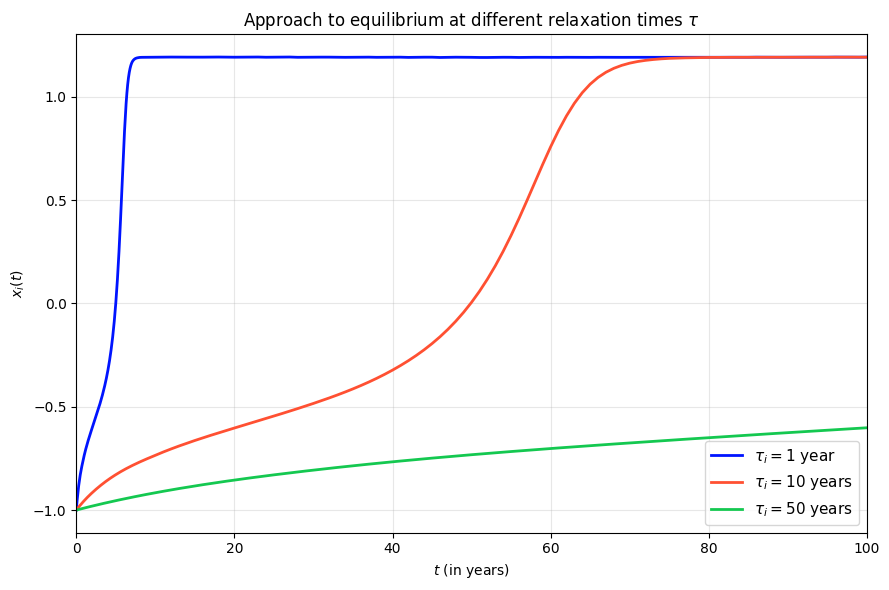

In [5]:

alpha, beta, mu_fixed = 1.0, 1.0, 0.5
x0 = -1.0
t_eval = np.concatenate([np.arange(0, 9, 0.1), np.arange(10, 1001, 1.0)])

def cubic_rhs(t, x, tau):
    return [(alpha * x[0] - beta * x[0] ** 3 + mu_fixed) / tau]

x_eq = bisection(lambda x: alpha * x - beta * x**3 + mu_fixed, 1.0, 1.5)
print(f"Equilibrium x* = {x_eq:.6f}")

fig, ax = plt.subplots(figsize=(9, 6))
colors = {1: color_blue, 10: color_red, 50: color_green}
for tau in (1, 10, 50):
    sol = solve_ivp(cubic_rhs, [t_eval[0], t_eval[-1]], [x0], t_eval=t_eval, args=(tau,), method="RK45")
    ax.plot(t_eval, sol.y[0], "-", color=colors[tau], linewidth=2.0, label=rf"$\tau_i = {tau}$ year" + ("s" if tau > 1 else ""))

ax.set_xlabel("$t$ (in years)"); ax.set_ylabel(r"$x_i(t)$")
ax.set_xlim(0, 100)
ax.grid(True, alpha=0.3)
ax.legend(loc="lower right", fontsize=11)
ax.set_title(r"Approach to equilibrium at different relaxation times $\tau$")
plt.tight_layout()
plt.show()


## 5. Cascading / coupled tipping points (`chap8_physic5c`)

Now couple a *second* cubic tipping element ("element 2") to the state of
a first one ("element 1") through a coupling term: element 2's own
bifurcation parameter becomes $\mu_2 + \gamma_{21} x_1^\star$ rather than a
fixed $\mu_2$. As element 1 settles at different equilibria
$x_1^\star \in \{5, -6, -10\}$, the *effective* control parameter felt by
element 2 shifts along its own fold diagram — illustrating how one tipping
element crossing its own threshold can push a second, otherwise-stable
element toward (or past) its own fold point.


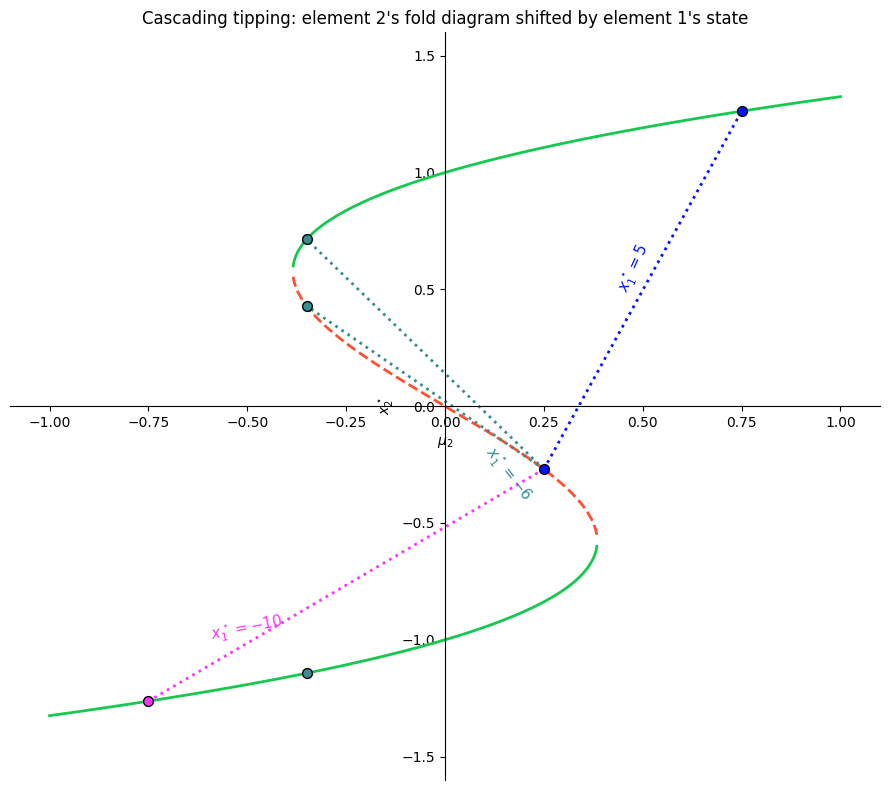

In [6]:

gamma_21 = 0.10
mu2_base = 0.25

def cubic_roots_stable(mu2_eff):
    c = np.array([-beta, 0, alpha, mu2_eff]) / tau
    return np.sort(np.roots(c)[np.abs(np.roots(c).imag) < 1e-9].real)

x2_c1 = cubic_roots_stable(mu2_base)
mu2_c1, x2_val_c1 = mu2_base, x2_c1[1] if len(x2_c1) >= 2 else x2_c1[-1]

x1_c2 = 5.0
mu2_c2 = mu2_base + gamma_21 * x1_c2
x2_c2 = cubic_roots_stable(mu2_c2)
x2_val_c2 = x2_c2[0]

x1_c3 = -6.0
mu2_c3 = mu2_base + gamma_21 * x1_c3
x2_c3 = cubic_roots_stable(mu2_c3)
mu2_c3_arr = np.full(len(x2_c3), mu2_c3)

x1_c4 = -10.0
mu2_c4 = mu2_base + gamma_21 * x1_c4
x2_c4 = cubic_roots_stable(mu2_c4)
x2_val_c4 = x2_c4[0]
mu2_c4_arr = np.full(1, mu2_c4)

fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(mu, x_star[:, 0], "-", color=color_green, linewidth=2.0)
ax.plot(mu, x_star[:, 1], "--", color=color_red, linewidth=2.0)
ax.plot(mu, x_star[:, 2], "-", color=color_green, linewidth=2.0)

ax.scatter([mu2_c1], [x2_val_c1], s=50, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.scatter([mu2_c2], [x2_val_c2], s=50, facecolor=color_blue, edgecolor=color_black, zorder=5)
ax.scatter(mu2_c3_arr, x2_c3, s=50, facecolor=color_teal, edgecolor=color_black, zorder=5)
ax.scatter(mu2_c4_arr, [x2_val_c4], s=50, facecolor=color_violet, edgecolor=color_black, zorder=5)

ax.plot([mu2_c1, mu2_c2], [x2_val_c1, x2_val_c2], ":", color=color_blue, linewidth=2.0)
if len(x2_c3) >= 3:
    ax.plot([mu2_c1, mu2_c3], [x2_val_c1, x2_c3[1]], ":", color=color_teal, linewidth=2.0)
    ax.plot([mu2_c1, mu2_c3], [x2_val_c1, x2_c3[2]], ":", color=color_teal, linewidth=2.0)
ax.plot([mu2_c1, mu2_c4], [x2_val_c1, x2_val_c4], ":", color=color_violet, linewidth=2.0)

ax.annotate(r"$x_1^\star = 5$", xy=(0.48, 0.5), color=color_blue, rotation=65, ha="center", fontsize=11)
ax.annotate(r"$x_1^\star = -6$", xy=(0.16, -0.4), color=color_teal, rotation=-51.5, ha="center", fontsize=11)
ax.annotate(r"$x_1^\star = -10$", xy=(-0.5, -1.0), color=color_violet, rotation=11, ha="center", fontsize=11)

ax.set_xlabel(r"$\mu_2$"); ax.set_ylabel(r"$x_2^\star$")
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.6, 1.6)
ax.spines["left"].set_position("zero"); ax.spines["bottom"].set_position("zero")
ax.spines["right"].set_visible(False); ax.spines["top"].set_visible(False)
ax.set_title(r"Cascading tipping: element 2's fold diagram shifted by element 1's state")
plt.tight_layout()
plt.show()


## 6. The full coupling surface (`chap8_physic5d`)

Finally, extend the previous figure into a full 2-D parameter surface: for
every combination of $\mu_2$ and $x_1^\star$ (not just the three sample
values used above), compute element 2's equilibria and split them into the
stable-lower, unstable, and stable-upper branches. Each becomes a 3-D
surface $x_2^\star(\mu_2, x_1^\star)$ — the previous figure's dotted
connector lines are literally slices through these three surfaces at fixed
$x_1^\star$.


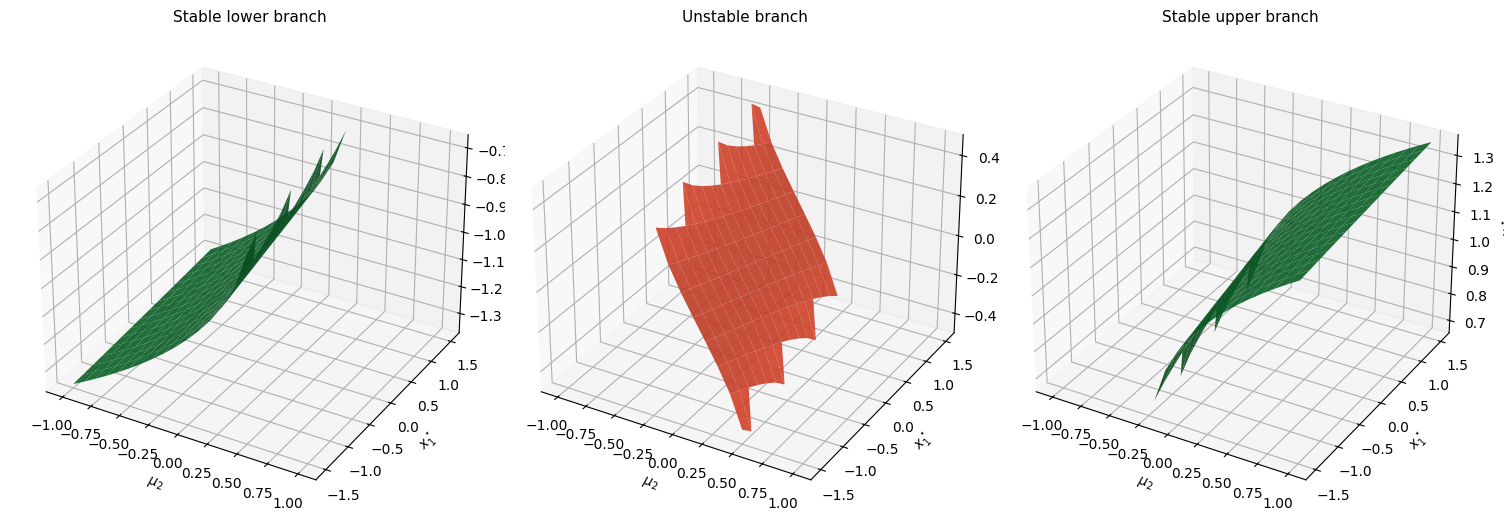

In [7]:

mu2_grid = np.arange(-1.0, 1.001, 0.10)
x1_grid = np.arange(-1.5, 1.501, 0.20)
n_mu2, n_x1 = len(mu2_grid), len(x1_grid)

x2_lower = np.full((n_mu2, n_x1), np.nan)
x2_mid = np.full((n_mu2, n_x1), np.nan)
x2_upper = np.full((n_mu2, n_x1), np.nan)

fold = np.sqrt(1 / 3)
for j, x1v in enumerate(x1_grid):
    for i, mu2v in enumerate(mu2_grid):
        c_eff = mu2v + gamma_21 * x1v
        c = np.array([-beta, 0, alpha, c_eff]) / tau
        roots = np.roots(c)
        x = np.sort(roots[np.abs(roots.imag) < 1e-9].real)
        for xv in x:
            if xv <= -fold:
                x2_lower[i, j] = xv
            elif xv >= fold:
                x2_upper[i, j] = xv
            else:
                x2_mid[i, j] = xv

Mu2, X1 = np.meshgrid(mu2_grid, x1_grid, indexing="ij")

fig = plt.figure(figsize=(15, 6))
titles_data = [("Stable lower branch", x2_lower, color_green),
               ("Unstable branch", x2_mid, color_red),
               ("Stable upper branch", x2_upper, color_green)]
for k, (title, Z, c) in enumerate(titles_data):
    ax = fig.add_subplot(1, 3, k + 1, projection="3d")
    ax.plot_surface(Mu2, X1, Z, color=c, edgecolor="none", alpha=0.9)
    ax.set_xlabel(r"$\mu_2$"); ax.set_ylabel(r"$x_1^\star$"); ax.set_zlabel(r"$x_2^\star$")
    ax.set_title(title, fontsize=11)

plt.tight_layout()
plt.show()


## Summary

This notebook completes the abstract dynamical-systems half of Chapter 8's
physics group: the four canonical bifurcation normal forms, a worked
chaotic system (Rössler) with its three bifurcation diagrams, and a
cubic-normal-form illustration of relaxation dynamics and cascading /
coupled tipping points. Together with `08a`-`08c`, this closes out the
"physics" sub-notebooks proper — `08e`-`08g` (anthropogenic emissions,
palaeoclimate, scientific consensus) still remain in Part 1.

**Reused from `08c`:** the `bisection` helper (faithful port of
`QuantToolbox/optim/bisection.m`, NaN-on-no-bracket semantics) is used
again here in section 4 — its second use across notebooks, so it graduates
from a one-off candidate to a confirmed-reusable primitive in
`PACKAGING_CANDIDATES.md`.

**New candidate for `PACKAGING_CANDIDATES.md`:** `missex(x, cond)`, a small
generic "set to NaN wherever condition holds" utility mirroring GAUSS's own
`missex` function, used four times in section 1 alone. Likely to recur
anywhere else in the `hfs-archive` source that uses GAUSS's `missex`
convention for branch-splitting a swept parameter array.

**Deliberate resolution reduction (documented above):** `chap8_physic4g`'s
three bifurcation-diagram sweeps were run at half the source MATLAB's grid
density (~475 vs. ~950 total ODE solves) to keep build time tractable,
while keeping a tighter-than-default integrator tolerance to preserve the
qualitative bifurcation structure.
